In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv(r"credit_card_fraud_10k.csv")

In [3]:
df.head()

,transaction_id,amount,transaction_hour,merchant_category,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
0,1,84.47,22,Electronics,0,0,66,3,40,0
1,2,541.82,3,Travel,1,0,87,1,64,0
2,3,237.01,17,Grocery,0,0,49,1,61,0
3,4,164.33,4,Grocery,0,1,72,3,34,0
4,5,30.53,15,Food,0,0,79,0,44,0


In [4]:
df.tail()

,transaction_id,amount,transaction_hour,merchant_category,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
9995,9996,350.91,22,Food,0,0,99,4,37,0
9996,9997,410.04,5,Clothing,0,0,70,3,25,0
9997,9998,527.75,21,Electronics,0,0,44,2,45,0
9998,9999,91.20,2,Electronics,0,0,38,0,37,0
9999,10000,44.06,2,Clothing,0,0,38,0,66,0


In [5]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   transaction_id       10000 non-null  int64  
 1   amount               10000 non-null  float64
 2   transaction_hour     10000 non-null  int64  
 3   merchant_category    10000 non-null  object 
 4   foreign_transaction  10000 non-null  int64  
 5   location_mismatch    10000 non-null  int64  
 6   device_trust_score   10000 non-null  int64  
 7   velocity_last_24h    10000 non-null  int64  
 8   cardholder_age       10000 non-null  int64  
 9   is_fraud             10000 non-null  int64  
dtypes: float64(1), int64(8), object(1)
memory usage: 781.4+ KB


In [6]:
df.describe()

,transaction_id,amount,transaction_hour,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,175.949849,11.593300,0.097800,0.085700,61.798900,2.008900,43.468700,0.015100
std,2886.89568,175.392827,6.922708,0.297059,0.279935,21.487053,1.432559,14.979147,0.121957
min,1.00000,0.000000,0.000000,0.000000,0.000000,25.000000,0.000000,18.000000,0.000000
25%,2500.75000,50.905000,6.000000,0.000000,0.000000,43.000000,1.000000,30.000000,0.000000
50%,5000.50000,122.095000,12.000000,0.000000,0.000000,62.000000,2.000000,44.000000,0.000000
75%,7500.25000,242.480000,18.000000,0.000000,0.000000,80.000000,3.000000,56.000000,0.000000
max,10000.00000,1471.040000,23.000000,1.000000,1.000000,99.000000,9.000000,69.000000,1.000000


In [7]:
df.shape

(10000, 10)

### Checking Missing Values ###

In [8]:
df.isnull().sum()

transaction_id         0
amount                 0
transaction_hour       0
merchant_category      0
foreign_transaction    0
location_mismatch      0
device_trust_score     0
velocity_last_24h      0
cardholder_age         0
is_fraud               0
dtype: int64

In [9]:
df.isna().sum()

transaction_id         0
amount                 0
transaction_hour       0
merchant_category      0
foreign_transaction    0
location_mismatch      0
device_trust_score     0
velocity_last_24h      0
cardholder_age         0
is_fraud               0
dtype: int64

In [10]:
df.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
9995    False
9996    False
9997    False
9998    False
9999    False
Length: 10000, dtype: bool

In [11]:
df.nunique()

transaction_id         10000
amount                  8788
transaction_hour          24
merchant_category          5
foreign_transaction        2
location_mismatch          2
device_trust_score        75
velocity_last_24h         10
cardholder_age            52
is_fraud                   2
dtype: int64

In [12]:
df['is_fraud'].value_counts()

is_fraud
0    9849
1     151
Name: count, dtype: int64

In [13]:
df.drop('transaction_id', axis=1,inplace=True)

### FRAUD DISTRIBUTION ###

Fraud Rate: 1.51%


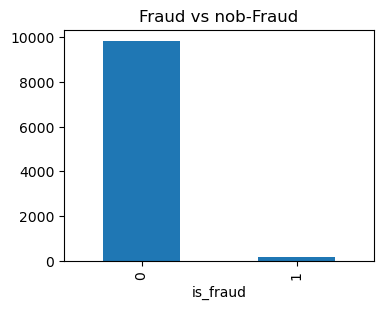

In [14]:
fraud_counts = df["is_fraud"].value_counts()
fraud_rate = df["is_fraud"].mean() * 100

print(f"Fraud Rate: { fraud_rate:.2f}%")

plt.figure(figsize=(4,3))
fraud_counts.plot(kind = "bar")
plt.title("Fraud vs nob-Fraud")
plt.show()

### Numeric Distributions ###

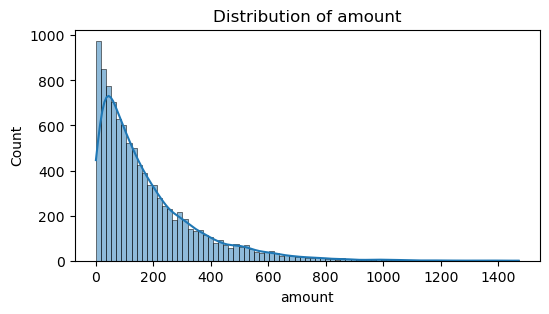

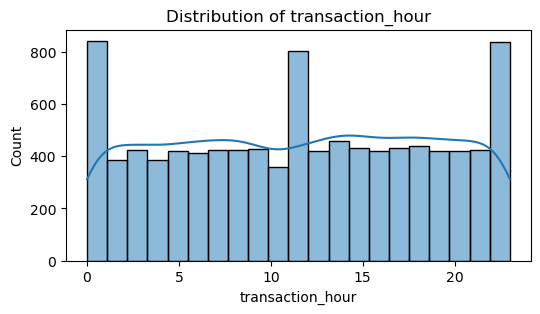

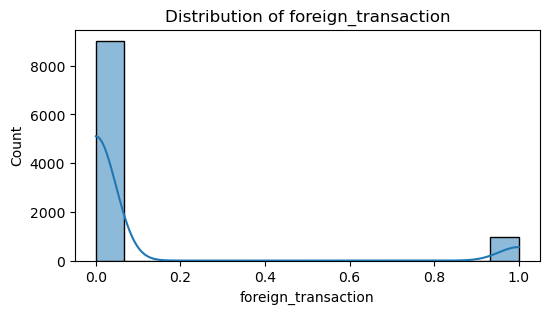

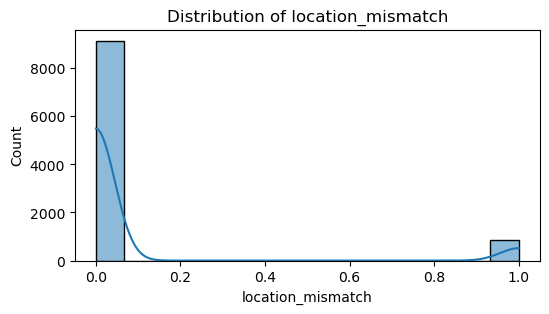

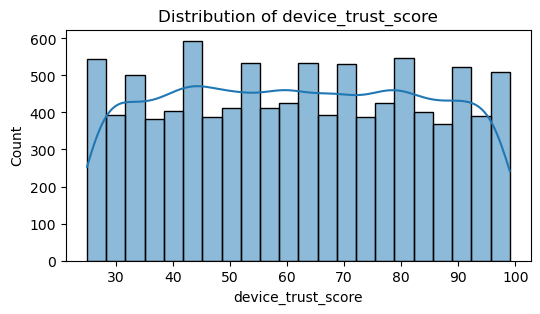

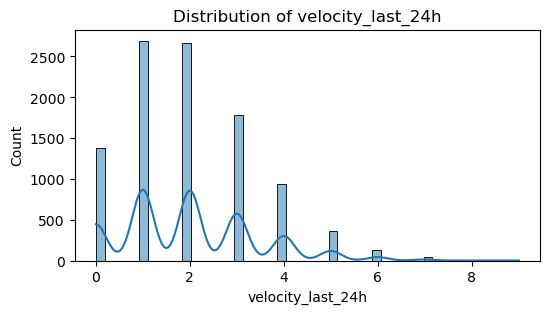

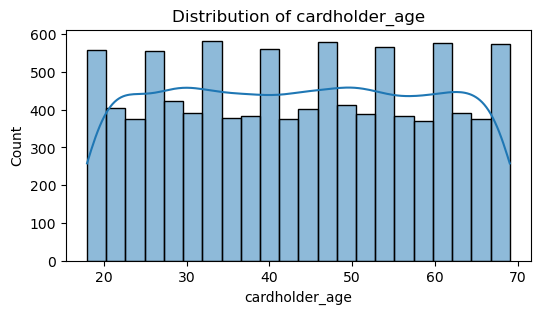

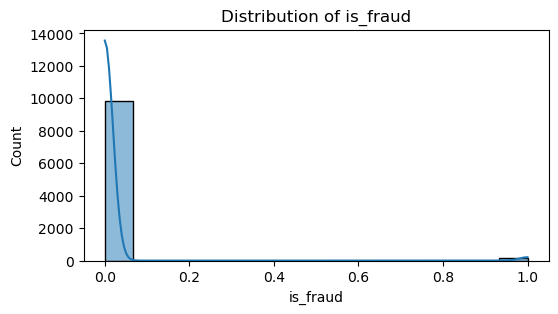

In [15]:
num_cols = df. select_dtypes(include=np.number).columns

for col in num_cols:
    if col !="transaction_id":
        plt.figure(figsize=(6,3))
        sns.histplot(df[col], kde= True)
        plt.title(f"Distribution of { col}")
        plt.show()

### Outlier Analysis ###

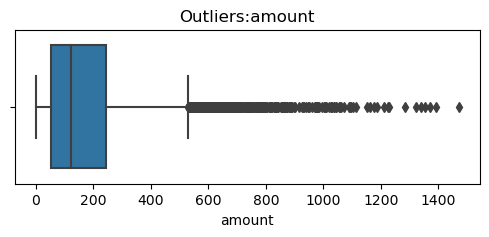

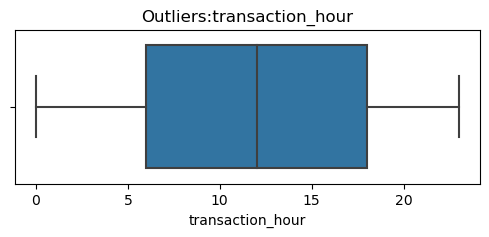

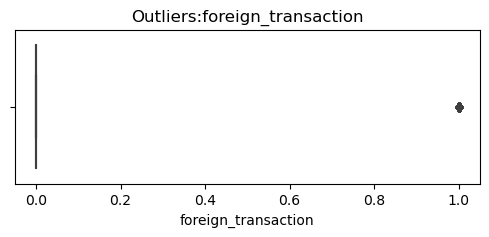

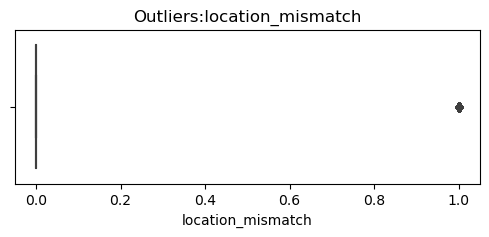

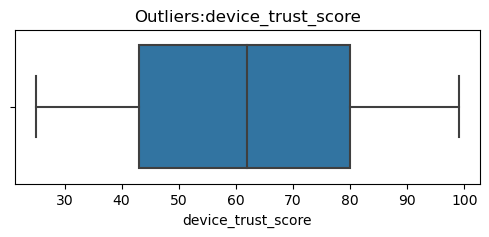

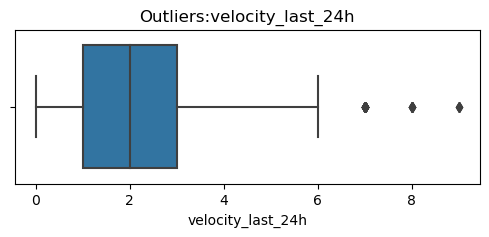

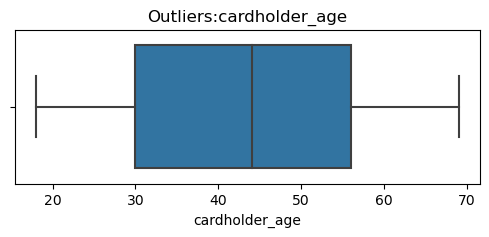

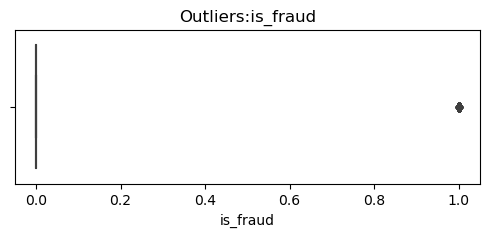

In [16]:
for col in num_cols:
    if col != "transaction_id":
        plt.figure(figsize=(6,2))
        sns.boxplot(x=df[col])
        plt.title(f"Outliers:{col}")
        plt.show()

### Fraud Behavior Analysis ###

In [17]:
group_stats = df.groupby("is_fraud").mean(numeric_only=True)
group_stats

,amount,transaction_hour,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age
is_fraud,,,,,,,
0,175.333015,11.712154,0.090974,0.079704,62.165804,1.990557,43.469794
1,216.182980,3.841060,0.543046,0.476821,37.867550,3.205298,43.397351


### Foreign & Location Risk ###


Fraud % by foreign_transaction:
 is_fraud                 0     1
foreign_transaction             
0                    99.24  0.76
1                    91.62  8.38


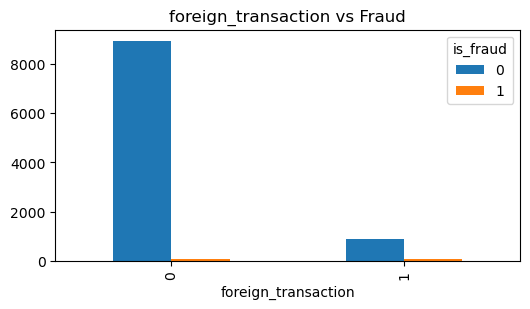


Fraud % by location_mismatch:
 is_fraud               0     1
location_mismatch             
0                  99.14  0.86
1                  91.60  8.40


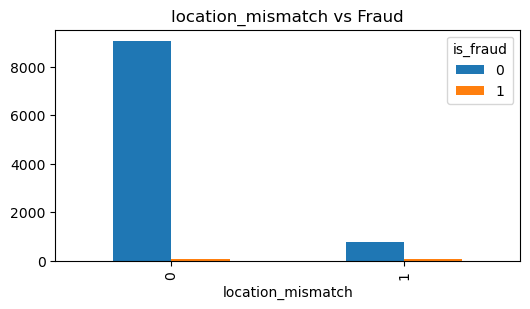

In [18]:
binary_cols = ["foreign_transaction", "location_mismatch"]
for col in binary_cols:
    table = pd.crosstab(df[col], df["is_fraud"], normalize="index") * 100
    print(f"\nFraud % by { col}:\n", table.round(2))
    pd.crosstab(df[col], df["is_fraud"]).plot(kind = "bar", figsize= (6,3))
    plt.title(f"{col} vs Fraud")
    plt.show()
    

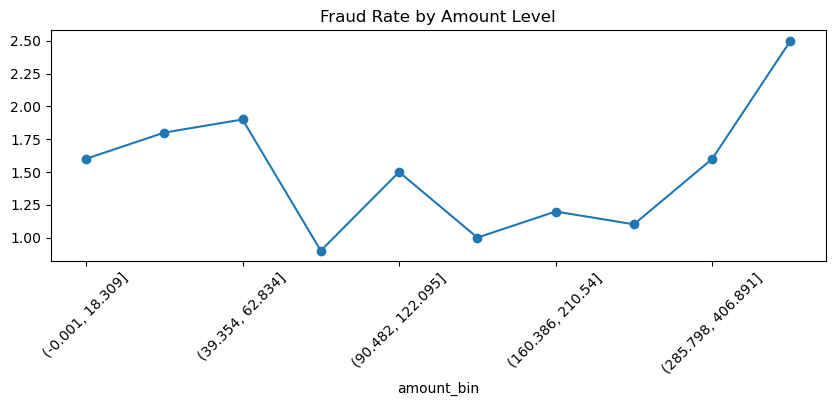

In [19]:
### Amount Risk Level 
df["amount_bin"] = pd.qcut(df["amount"], q=10)

amount_risk = df.groupby("amount_bin")["is_fraud"].mean() * 100 

plt.figure(figsize=(10,3))
amount_risk.plot(marker ="o")
plt.title("Fraud Rate by Amount Level")
plt.xticks(rotation = 45)
plt.show()

### TRANSACTION HOUR PATTERN ###

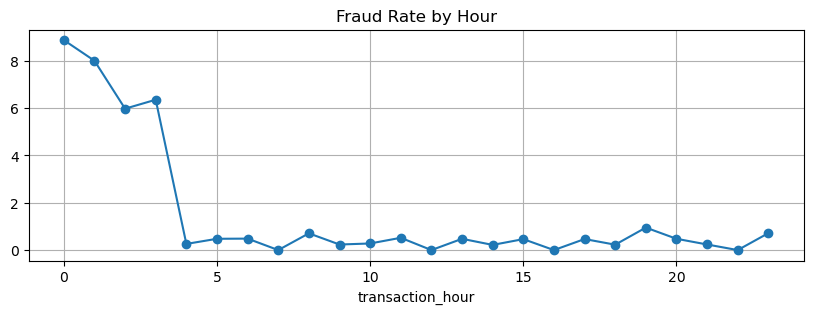

In [20]:
hour_pattern = df.groupby("transaction_hour")["is_fraud"].mean() * 100 
plt.figure(figsize=(10,3))

hour_pattern.plot(marker="o")
plt.title("Fraud Rate by Hour")
plt.grid(True)
plt.show()


### DEVICE TRUST SCORE ###

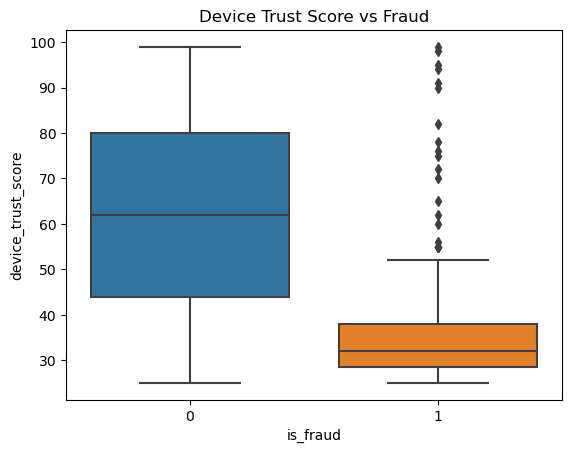

In [21]:
sns.boxplot(data=df, x="is_fraud", y ="device_trust_score")
plt.title("Device Trust Score vs Fraud")
plt.show()

### VELOCITY ANALYSIS ### 

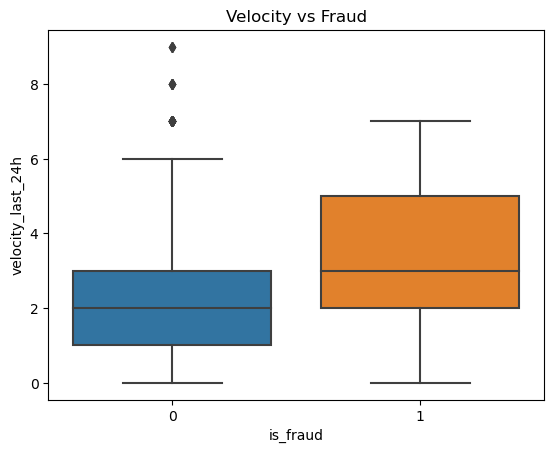

In [22]:
sns.boxplot(data=df, x="is_fraud", y="velocity_last_24h")
plt.title("Velocity vs Fraud")
plt.show()

### Corelation Matrix ###

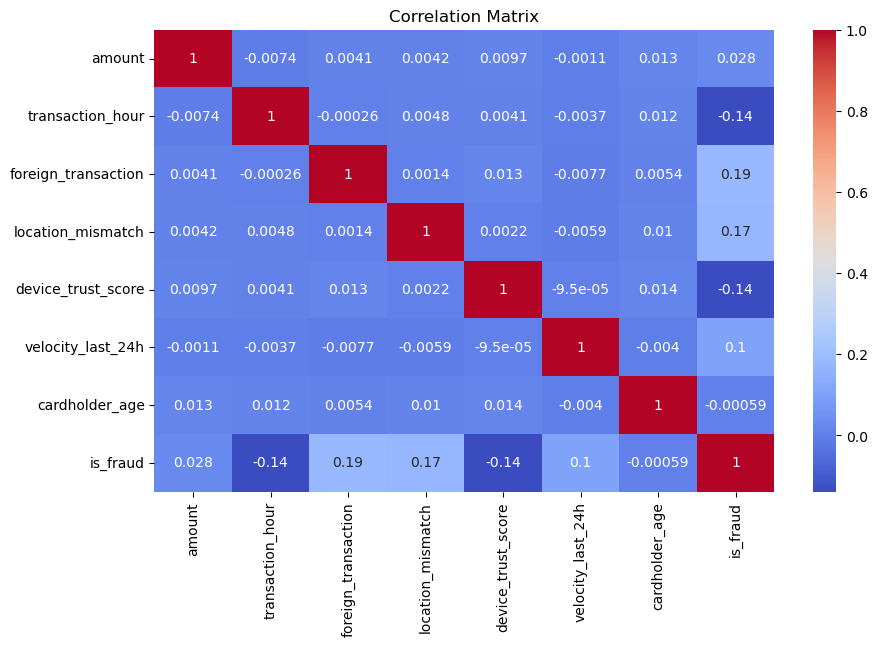

In [23]:
corr = df.corr(numeric_only = True)

plt.figure(figsize=(10,6))
sns.heatmap(corr, annot= True, cmap ="coolwarm")
plt.title("Correlation Matrix")
plt.show()

### RULE-BASED RISK SCORE ###

In [24]:
df2= df.copy()
vel_thr = df2["velocity_last_24h"].quantile(0.9)
trust_thr = df2["device_trust_score"].quantile(0.1)

df2["risk_score"] = 0 
df2["risk_score"] += (df2["foreign_transaction"]==1).astype(int)
df2["risk_score"] += (df2["velocity_last_24h"]>=vel_thr).astype(int)
df2["risk_score"] += (df2["velocity_last_24h"]>=vel_thr).astype(int)
df2["risk_score"] += (df2["velocity_last_24h"]>=vel_thr).astype(int)

risk_analysis = df2.groupby("risk_score")["is_fraud"].mean() * 100
risk_analysis

risk_score
0     0.377703
1     6.539834
3     2.976190
4    19.708029
Name: is_fraud, dtype: float64

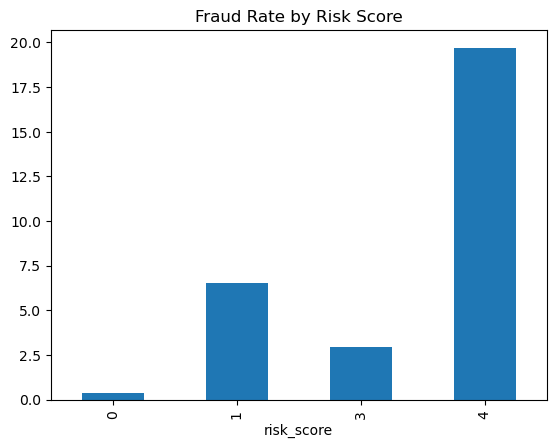

In [25]:
risk_analysis.plot(kind="bar")
plt.title("Fraud Rate by Risk Score")
plt.show()

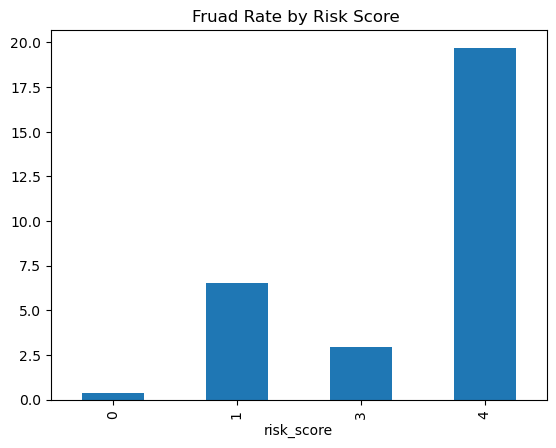

In [26]:
risk_analysis.plot(kind="bar")
plt.title("Fruad Rate by Risk Score ")
plt.show()

### MERCHANT CATEGORY HOTSPOTS ### 

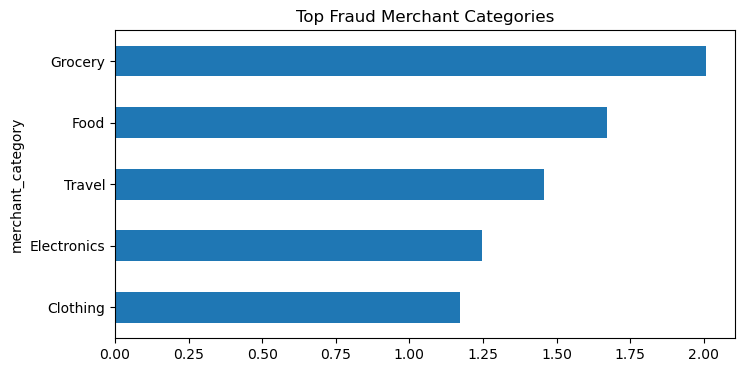

In [27]:
cat_risk = df.groupby("merchant_category")["is_fraud"].mean().sort_values(ascending= False) * 100 

top10 = cat_risk.head(10)

top10.sort_values().plot(kind="barh", figsize=(8,4))
plt.title("Top Fraud Merchant Categories")

plt.show()

### Merchant Category Hotspots ###

In [28]:
# 1. separate features and target
X= df.drop(["is_fraud","amount_bin"], axis=1)
y = df["is_fraud"]


In [29]:
# convert  categorical columns 
X=pd.get_dummies(X,drop_first = True)


### train-test split ###

In [30]:
from sklearn.model_selection import train_test_split 

X_train, X_test, y_train, y_test = train_test_split(
X, y,
test_size = 0.2,
random_state=42,
stratify=y
) 

In [31]:
# normalize data 
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

In [32]:
!pip install --upgrade scikit-learn imbalanced-learn

In [33]:
!pip install xgboost

In [34]:
# apply SMOTE only on training data
from imblearn.over_sampling import SMOTE 
from collections import Counter 

print("Before SMOTE:", Counter(y_train))

smote = SMOTE(random_state=42)
X_train_smote,y_train_smote = smote.fit_resample(X_train_scaled,y_train)

print("After SMOTE:", Counter(y_train_smote))


Before SMOTE: Counter({0: 7879, 1: 121})
After SMOTE: Counter({0: 7879, 1: 7879})


In [35]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from xgboost import XGBClassifier

In [36]:
#train logistic Regression
log_model = LogisticRegression(max_iter = 1000, random_state= 42)
log_model.fit(X_train_smote, y_train_smote)

y_pred_log = log_model.predict(X_test_scaled)
y_prob_log = log_model.predict_proba(X_test_scaled)[:,1]

print("Logistiv Regression Results")
print(confusion_matrix(y_test,y_pred_log))
print(classification_report(y_test, y_pred_log))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_log))


Logistiv Regression Results
[[1901   69]
 [   2   28]]
              precision    recall  f1-score   support

           0       1.00      0.96      0.98      1970
           1       0.29      0.93      0.44        30

    accuracy                           0.96      2000
   macro avg       0.64      0.95      0.71      2000
weighted avg       0.99      0.96      0.97      2000

ROC-AUC: 0.9933333333333334


In [37]:
#train random forest

rf_model = RandomForestClassifier(
 n_estimators=200,
max_depth=10,
random_state= 42
)
rf_model.fit(X_train_smote,y_train_smote)

y_pred_rf = rf_model.predict(X_test_scaled)
y_prob_rf = rf_model.predict_proba(X_test_scaled)[:,1]

print("Random Forest Results")
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))

Random Forest Results
[[1962    8]
 [   6   24]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1970
           1       0.75      0.80      0.77        30

    accuracy                           0.99      2000
   macro avg       0.87      0.90      0.89      2000
weighted avg       0.99      0.99      0.99      2000

ROC-AUC: 0.9977157360406093


In [38]:
xgb_model  = XGBClassifier(
 n_estimators = 200,
  max_depth = 5,
learning_rate=0.1,
random_state=42,
eval_metric="aucpr"
)

xgb_model.fit(X_train_smote, y_train_smote)

y_pred_xgb = xgb_model.predict(X_test_scaled)
y_prob_xgb = xgb_model.predict_proba(X_test_scaled)[:, 1]


print("XGBoost Results")
print(confusion_matrix(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_xgb))



XGBoost Results
[[1964    6]
 [   0   30]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1970
           1       0.83      1.00      0.91        30

    accuracy                           1.00      2000
   macro avg       0.92      1.00      0.95      2000
weighted avg       1.00      1.00      1.00      2000

ROC-AUC: 0.9995939086294416


In [39]:
# compare all models
results = {
    "Logistic Regression" : roc_auc_score(y_test, y_prob_log),
    "Random Forest": roc_auc_score(y_test, y_prob_rf),
    "XGBoost": roc_auc_score(y_test, y_prob_xgb)
}
results

{'Logistic Regression': 0.9933333333333334,
 'Random Forest': 0.9977157360406093,
 'XGBoost': 0.9995939086294416}

In [40]:
#comparision table 

comparsion = pd.DataFrame({
    "Model": list(results.keys()),
    "ROC-AUC Score": list(results. values())
})
comparsion

,Model,ROC-AUC Score
0,Logistic Regression,0.993333
1,Random Forest,0.997716
2,XGBoost,0.999594


In [41]:
from sklearn.metrics import accuracy_score, f1_score,precision_score, recall_score, confusion_matrix, classification_report, roc_auc_score
import pandas as pd

In [42]:
# evaluate Model

models={
    "logistic Regression": log_model,
    "Random Forest" : rf_model,
    "XGBoost": xgb_model
}
results = []

for name, model in models.items():
    
    # prediction 
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:,1]
    
    #scores
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    F1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)
    
    #Store result
    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 score": F1, 
        "ROC-AUC": roc_auc
    })
    
    print("="*50)
    print(name)
    print("="*50)
    print("confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print("\n Classification Report:")
    print(classification_report(y_test, y_pred))
    
    # comparison table 
    results_df = pd.DataFrame(results)
    results_df

logistic Regression
confusion Matrix:
[[1901   69]
 [   2   28]]

 Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.96      0.98      1970
           1       0.29      0.93      0.44        30

    accuracy                           0.96      2000
   macro avg       0.64      0.95      0.71      2000
weighted avg       0.99      0.96      0.97      2000

Random Forest
confusion Matrix:
[[1962    8]
 [   6   24]]

 Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1970
           1       0.75      0.80      0.77        30

    accuracy                           0.99      2000
   macro avg       0.87      0.90      0.89      2000
weighted avg       0.99      0.99      0.99      2000

XGBoost
confusion Matrix:
[[1964    6]
 [   0   30]]

 Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      

In [43]:
# to check all the available columns
print(results_df.columns)

Index(['Model', 'Accuracy', 'Precision', 'Recall', 'F1 score', 'ROC-AUC'], dtype='object')


### In fraud detection System, model priority should depend on
1. Recall for class 1 
2. F1-score for class 1
3. Precision for class 1
4. ROC-AUC


1.High recall = model catches more fraud cases
High precision = fewer false fraud alerts
High F1-score = balance between precision and recall


In [44]:
results_df.sort_values(by
                       =["Recall", "F1 score", "ROC-AUC"], ascending=False)


,Model,Accuracy,Precision,Recall,F1 score,ROC-AUC
2,XGBoost,0.9970,0.833333,1.000000,0.909091,0.999594
0,logistic Regression,0.9645,0.288660,0.933333,0.440945,0.993333
1,Random Forest,0.9930,0.750000,0.800000,0.774194,0.997716


In [45]:
results_df[["Model", "Precision", "Recall", "F1 score"]]

,Model,Precision,Recall,F1 score
0,logistic Regression,0.288660,0.933333,0.440945
1,Random Forest,0.750000,0.800000,0.774194
2,XGBoost,0.833333,1.000000,0.909091


In [46]:
# cross- validation
from imblearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_val_score
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler



In [47]:
pipeline=Pipeline([
    ("scaler", StandardScaler()),
    ("smote", SMOTE(random_state=42)),
    ("model", XGBClassifier(
      n_estimators=300,
       max_depth= 4,
       learning_rate=0.05,
       subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="aucpr"
    ))
])

cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(
        pipeline,
         X,
         y,
         cv=cv,
          scoring ="recall"
 )
    
print("Cross Validation Recall Scores:", scores)
print("Mean Recall:", scores.mean())
print("std Recall:", scores.std())

Cross Validation Recall Scores: [0.96666667 0.96666667 1.         0.9        0.93548387]
Mean Recall: 0.953763440860215
std Recall: 0.03375042554426548


In [50]:
print(X_train_smote.shape)
print(y_train_smote.shape)

(15758, 11)
(15758,)


In [55]:
# finalizing and savin the model 
from xgboost import XGBClassifier
import joblib

xgb_model = XGBClassifier(
    n_estimators= 200,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss'
)
xgb_model.fit(X_train_smote,y_train_smote)

joblib.dump(
    xgb_model,"fraud_detection_xgboost.pkl")

print("Model saved sucessfully !")

Model saved sucessfully !


In [56]:
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [57]:
# Feature Importance 

import pandas as pd
import matplotlib.pyplot as plt

#create dataframe of feature importances
feature_importance = pd.DataFrame({
    'Feature' : X_train.columns,
    'Importance' : xgb_model.feature_importances_
})

# sort descending 
feature_importance = feature_importance.sort_values(
        by='Importance',
        ascending=False
)

#display top 10 features
print(feature_importance.head(10))


                          Feature  Importance
1                transaction_hour    0.324615
3               location_mismatch    0.252860
4              device_trust_score    0.127514
2             foreign_transaction    0.109739
5               velocity_last_24h    0.097804
0                          amount    0.050201
10       merchant_category_Travel    0.017595
7   merchant_category_Electronics    0.008613
6                  cardholder_age    0.003840
9       merchant_category_Grocery    0.003745


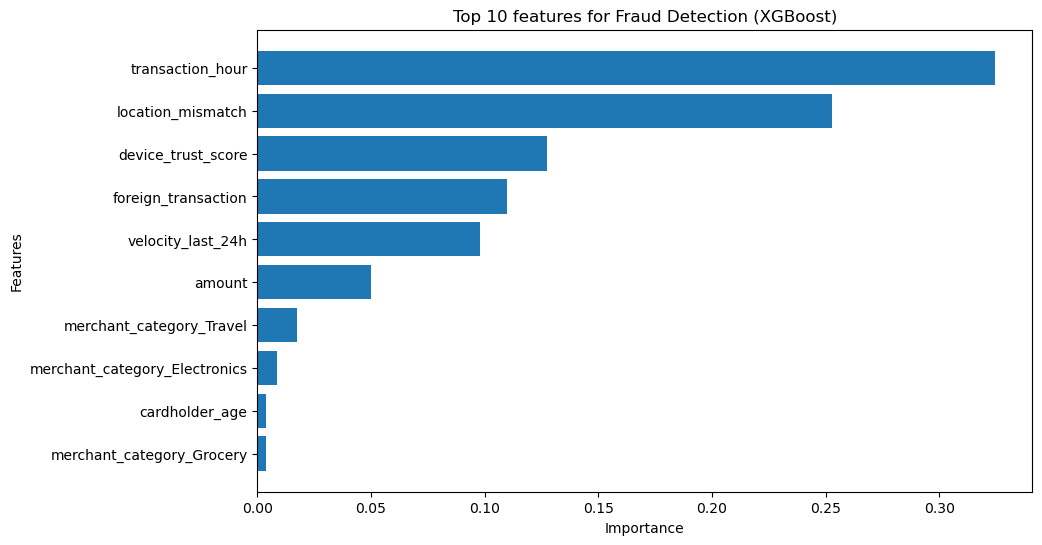

In [67]:
top10 = feature_importance.head(10)

plt.figure(figsize=(10,6))
plt.barh(top10['Feature'], top10['Importance'])
plt.xlabel("Importance")
plt.ylabel("Features")
plt.title("Top 10 features for Fraud Detection (XGBoost)")
plt.gca().invert_yaxis()
plt.show()

In [68]:
feature_name = X_train.columns.tolist()

joblib.dump(
    feature_name,
    "feature_name.pkl"
)

['feature_name.pkl']

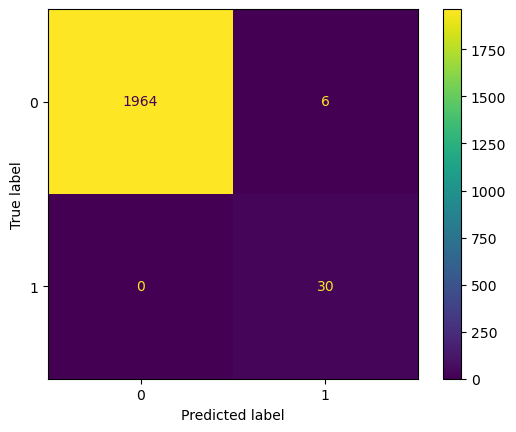

In [69]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_xgb
)
plt.show()

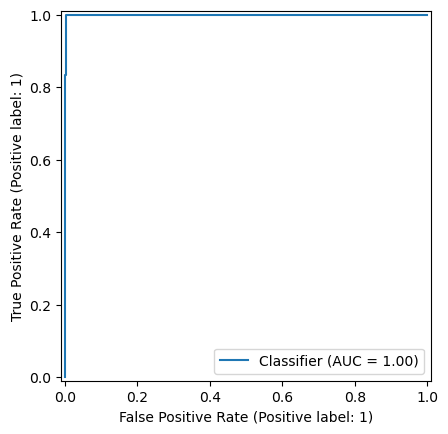

In [70]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_predictions(
    y_test,
    y_prob_xgb
)

plt.show()

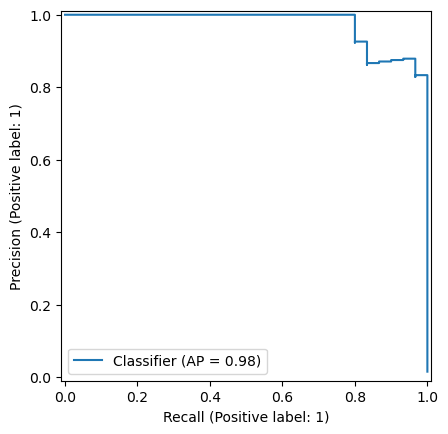

In [71]:
from sklearn.metrics import PrecisionRecallDisplay

PrecisionRecallDisplay.from_predictions(
    y_test,
    y_prob_xgb
)

plt.show()

In [72]:
#fraud Risk Cateogories:

def risk_level(prob):
    if prob <0.3:
        return "Low Risk"
    elif prob <0.7:
        return "Medium Risk"
    else:
        return "High Risk"

In [73]:
print(X_train.columns.tolist())

['amount', 'transaction_hour', 'foreign_transaction', 'location_mismatch', 'device_trust_score', 'velocity_last_24h', 'cardholder_age', 'merchant_category_Electronics', 'merchant_category_Food', 'merchant_category_Grocery', 'merchant_category_Travel']
